## Dataset Info

The study looked at the effectiveness of a job training program (the treatment) on the real earnings of an individual, a couple years after completion of the program.

The data consists of a number of demographic variables (age, race, academic background, and previous real earnings), as well as a treatment indicator, and the real earnings in the year 1978 (the response).

- treat is the treatment assignment (1=treated, 0=control).
- age is age in years.
- educ is education in number of years of schooling.
- black is an indicator for African-American (1=African-American, 0=not).
- hispan is an indicator for being of Hispanic origin (1=Hispanic, 0=not).
- married is an indicator for married (1=married, 0=not married).
- nodegree is an indicator for whether the individual has a high school degree (1=no degree, 0=degree).
- re74 is income in 1974, in U.S. dollars.
- re75 is income in 1975, in U.S. dollars.
- re78 is income in 1978, in U.S. dollars.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# https://pypi.org/project/CausalInference/
from causalinference import CausalModel

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('lalonde_data.csv')
df.head()

,ID,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,NSW1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
1,NSW2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
2,NSW3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
3,NSW4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
4,NSW5,1,33,8,1,0,0,1,0.0,0.0,289.7899


In [5]:
df.describe()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.301303,27.363192,10.268730,0.395765,0.117264,0.415309,0.630293,4557.546569,2184.938207,6792.834483
std,0.459198,9.881187,2.628325,0.489413,0.321997,0.493177,0.483119,6477.964479,3295.679043,7470.730792
min,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,238.283425
50%,0.000000,25.000000,11.000000,0.000000,0.000000,0.000000,1.000000,1042.330000,601.548400,4759.018500
75%,1.000000,32.000000,12.000000,1.000000,0.000000,1.000000,1.000000,7888.498250,3248.987500,10893.592500
max,1.000000,55.000000,18.000000,1.000000,1.000000,1.000000,1.000000,35040.070000,25142.240000,60307.930000


In [6]:
# Look at the final earnings of the control at treated groups
df.groupby('treat')['re78'].agg(['median','mean'])

,median,mean
treat,,
0,4975.505,6984.169742
1,4232.309,6349.143530


At first glance, we don't see a very clear difference between the treated group and the control, at best a decrease in earnings, wich is the oposite of the initial hypthesis.
Before jumping to conclusiones, let's explroe the dataset to see how the experiment was perfromed

## Data Exploration

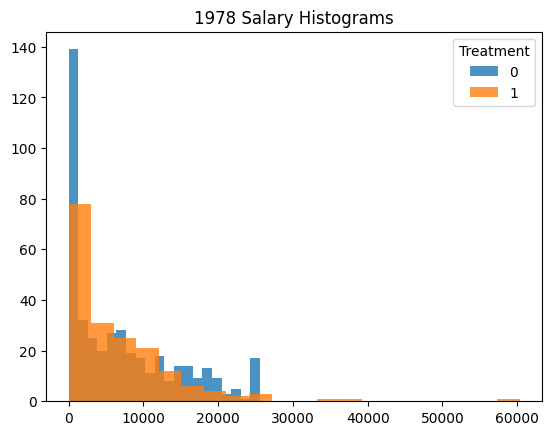

In [7]:
plt.hist(df[df['treat'] == 0]['re78'], bins=20, alpha=0.8, label='0')
plt.hist(df[df['treat'] == 1]['re78'], bins=20, alpha=0.8, label='1')
plt.title("1978 Salary Histograms")
plt.legend(title="Treatment")
plt.show()

From this resulting histogram, we can see that both groups are quite different. Lets explore the previous years to see if the differentiation is because of the treatment or a flaw from the beggining

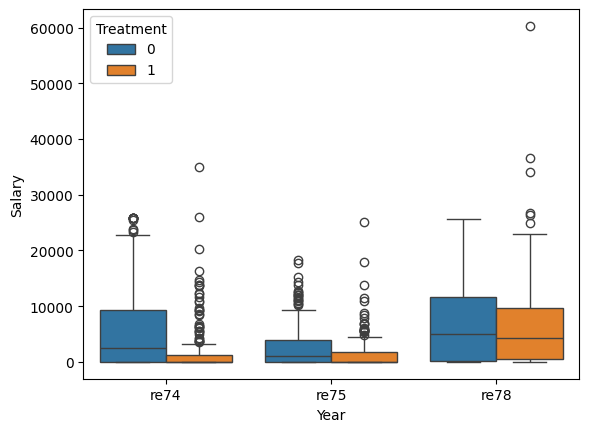

In [8]:
# reshape from wide → long
df_long = df.melt(id_vars='treat', 
                  value_vars=['re74', 're75', 're78'],
                  var_name='Treatment', 
                  value_name='Salary')

# plot
sns.boxplot(x='Treatment', y='Salary', hue='treat', data=df_long)
plt.xlabel('Year')
plt.ylabel('Salary')
plt.legend(title='Treatment')

plt.show()

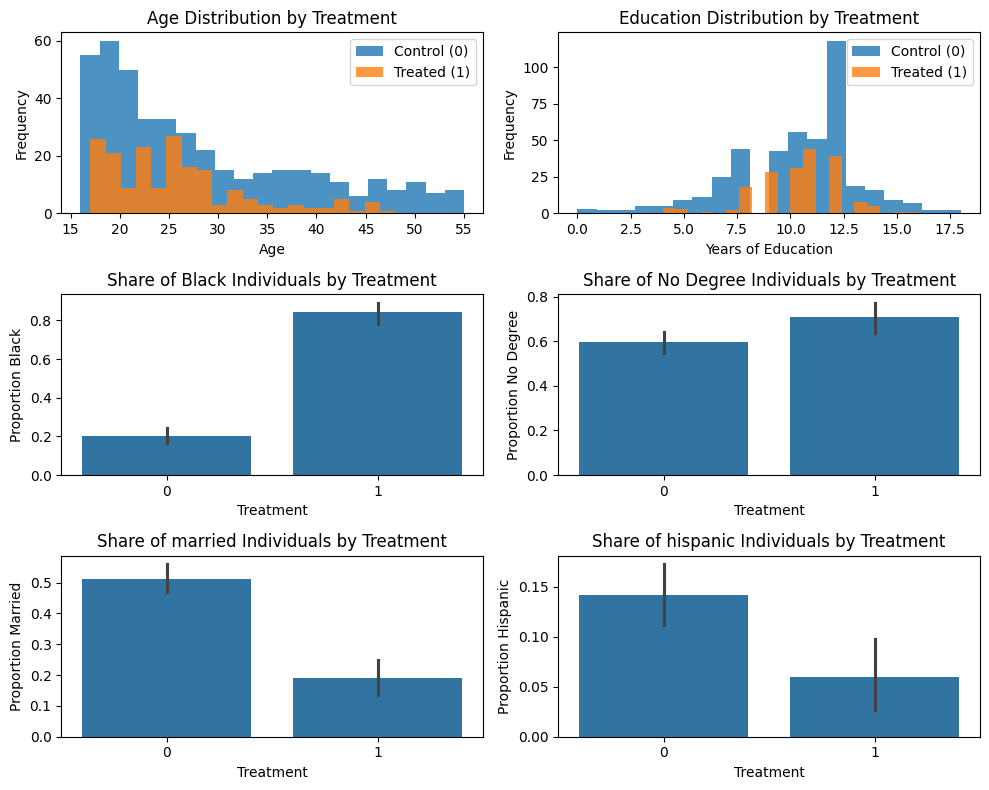

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8))

# --- Plot 1: age (top-left) ---
axes[0, 0].hist(df[df['treat'] == 0]['age'], bins=20, alpha=0.8, label='Control (0)')
axes[0, 0].hist(df[df['treat'] == 1]['age'], bins=20, alpha=0.8, label='Treated (1)')
axes[0, 0].set_title("Age Distribution by Treatment")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

# --- Plot 2: educ (top-right) ---
axes[0, 1].hist(df[df['treat'] == 0]['educ'], bins=20, alpha=0.8, label='Control (0)')
axes[0, 1].hist(df[df['treat'] == 1]['educ'], bins=20, alpha=0.8, label='Treated (1)')
axes[0, 1].set_title("Education Distribution by Treatment")
axes[0, 1].set_xlabel("Years of Education")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

# --- Plot 3: share of black (bottom-left) ---
sns.barplot(x='treat', y='black', data=df, estimator='mean', ax=axes[1, 0])
axes[1, 0].set_title("Share of Black Individuals by Treatment")
axes[1, 0].set_xlabel("Treatment")
axes[1, 0].set_ylabel("Proportion Black")

# --- Plot 4: share of nodegree (bottom-right) ---
sns.barplot(x='treat', y='nodegree', data=df, estimator='mean', ax=axes[1, 1])
axes[1, 1].set_title("Share of No Degree Individuals by Treatment")
axes[1, 1].set_xlabel("Treatment")
axes[1, 1].set_ylabel("Proportion No Degree")

# --- Plot 5: share of married (bottom-left) ---
sns.barplot(x='treat', y='married', data=df, estimator='mean', ax=axes[2, 0])
axes[2, 0].set_title("Share of married Individuals by Treatment")
axes[2, 0].set_xlabel("Treatment")
axes[2, 0].set_ylabel("Proportion Married")

# --- Plot 4: share of nodegree (bottom-right) ---
sns.barplot(x='treat', y='hispan', data=df, estimator='mean', ax=axes[2, 1])
axes[2, 1].set_title("Share of hispanic Individuals by Treatment")
axes[2, 1].set_xlabel("Treatment")
axes[2, 1].set_ylabel("Proportion Hispanic")
plt.tight_layout()
plt.show()

With these plots it is clear that the groups were very different from the beggining, meaning that we can't just say that the treatment had no effect, we need to control for all the variables (confounding variables)

# Simple Approach
The simplest type of model we can use is a linear model:

Y0=α+βX+ϵ

Y1=Y0+γD


If this is accurate, fitting the following model to the data using linear regression will give us an estimate of the Average Treatment Effect (ATE):
Y=α+βX+γD


ϵ
  is called a residual and represents the noise

In [10]:
covariates = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

In [11]:

causal = CausalModel(
    Y=df['re78'].values, 
    D=df['treat'].values, 
    X=df[covariates].values)

causal.est_via_ols(adj=1)
# adj=1 corresponds to the simplicity of the model we entered
# This is called a "constant treatment effect"

print(causal.estimates)


Treatment Effect Estimates: OLS

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904



This model predicts that the Average Treatment Effect (ATE, the job training) is $1548 extra annual earnings. This is very different from our previous raw results predicting that the job training had negative effects on earnings.

Assuming that our model accurately describes the counterfactual X, CausalModel provides the 95% confidence interval. What this means is that, if we were to repeat this treatment experiment, in 95% of the cases the Average Treatment Effect would be within that interval. That doesn't mean that the true value is within that interval.

Based on the assumption that the residuals are normally distributed, the 95% confidence interval is calculated as:
AVG±1.96∗STD/√‾n


In practice, as the confidence interval is very large, my interpretation is that the experiment should have had more people if a better estimate of the extra earnings was desired. Ways to control the standard deviation could also be explored.

Overall, assuming that we controlled for all the effects and did it well, it seems that the job training had a positive effect on earnings. Indeed, although the standard deviation is very large, the p value of 0.035 rejects the null hypothesis (no effect) with a confidence level of 97.5%. However, the truth is that we don't know if we modelled the counterfactual well, and this could change everything... As we will see later, estimators such as the Ordinary Least Square (OLS) estimator can behave poorly when there is not enough covariate overlap, and that's because the estimator needs to extrapolate too much from one group to another.

A more structured approach as we will see below can allow us to increase our confidence that the covariants are well controlled for. We will see many steps, but one simple idea is the technique of matching: the idea is to find for each sample which received the treatment a similar sample in the control group, and to directly compare these values.

# More complete approach
### Pre-processing phase:
1. assess covariate balance
2. estimate propensity score
3. trim sample
4. stratify sample

### Estimation phase:
1. blocking estimator or/and
2. matching estimator

## Pre-processing phase
In the pre-processing phase, the data is inspected and manipulated to allow credible analysis to be conducted on it.

As we discussed in the previous section, one key method for disantangling the treatment effect from the covariant effects is the matching technique. In this technique we compare subjects that have similar covariate values (i.e. same age, rage, income etc). However, our ability to compare such pairs depends heavily on the degree of overlap of the covariates between the treatment and control group. This is called covariate balance.

Said otherwise, to control the effect of education, one way is to look at people in the tested group and in the non-tested group that all have the same level of education, say a bachelor degree. However, if nobody in the test group has a bachelor degree while many do in the non-test group, this procedure is impossible.

(1) assess covariate balance to assess whether how easily people can be matched. If there is too much unbalance, direct matching will rarely be possible, and we may need to use more complex techniques, if at all possible.

In [12]:
df.columns

Index(['ID', 'treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree',
       're74', 're75', 're78'],
      dtype='str')

In [13]:
print(causal.summary_stats)


Summary Statistics

                       Controls (N_c=429)         Treated (N_t=185)             
       Variable         Mean         S.d.         Mean         S.d.     Raw-diff
--------------------------------------------------------------------------------
              Y     6984.170     7294.162     6349.144     7867.402     -635.026

                       Controls (N_c=429)         Treated (N_t=185)             
       Variable         Mean         S.d.         Mean         S.d.     Nor-diff
--------------------------------------------------------------------------------
             X0       28.030       10.787       25.816        7.155       -0.242
             X1       10.235        2.855       10.346        2.011        0.045
             X2        0.203        0.403        0.843        0.365        1.668
             X3        0.142        0.350        0.059        0.237       -0.277
             X4        0.513        0.500        0.189        0.393       -0.719
      

The aim here is to assess the overlap between the control and treatment groups. It can be seen that X2, X4, and X6 (black, married, revenue in 1974) have a large normalized difference, beyond 0.5. This can be interpreted as an imbalance. Concretely, there are way more black people, less married people and lower income in 1974 in the treatment group than in the control group, as previously shown in the exploratory section.

The impact of imbalance is to make the matching technique harder to apply. We'll see later how we can try to correct for it (however, ideally the study would be more balanced!).

(2) Propensity Score - the probability of receiving the treatment, conditional on the covariates.

Propensity is useful for assessing and improving covariate balance. Indeed a theorem by Rosenbaum and Rubin in 1983, proves that, for subjects that share the same propensity score (even if their covariate vectors are different), the difference between the treated and the control units actually identifies a conditional average treatment effect.

Thus, instead of matching on the covariate vectors X themselves, we can also match on the single-dimensional propensity score p(X), aggregate across subjects, and still arrive at a valid estimate of the overall average treatment effect.

In [14]:
causal.est_propensity_s()
print(causal.propensity)


Estimated Parameters of Propensity Score

                    Coef.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
     Intercept    -21.096      2.687     -7.851      0.000    -26.363    -15.829
            X2      2.635      0.367      7.179      0.000      1.915      3.354
            X4     -3.026      0.717     -4.222      0.000     -4.431     -1.621
            X6      0.000      0.000      0.847      0.397     -0.000      0.000
            X3      5.137      1.845      2.785      0.005      1.521      8.753
            X1      1.175      0.316      3.713      0.000      0.555      1.796
            X5      0.376      0.450      0.836      0.403     -0.505      1.258
            X7      0.000      0.000      1.496      0.135     -0.000      0.000
            X0      0.988      0.142      6.983      0.000      0.711      1.266
         X0*X0     -0.015      0.002     -6.524      0.000     -0.

(3) Trim sample. This excludes subjects with extreme propensity scores. Indeed it will be very hard to match those extreme subjects, so the usual strategy is to focus attention on the remaining units that exhibit a higher degree of covariate balance.

In [15]:
# extreme propensity is a very high probability to be either in the control group or the treatment group
# that makes matching difficult

causal.trim_s()
print(causal.summary_stats)


Summary Statistics

                       Controls (N_c=156)         Treated (N_t=140)             
       Variable         Mean         S.d.         Mean         S.d.     Raw-diff
--------------------------------------------------------------------------------
              Y     5511.740     6023.366     6351.987     6397.833      840.246

                       Controls (N_c=156)         Treated (N_t=140)             
       Variable         Mean         S.d.         Mean         S.d.     Nor-diff
--------------------------------------------------------------------------------
             X0       23.603        7.112       24.986        7.510        0.189
             X1       10.250        2.360       10.329        2.177        0.035
             X2        0.468        0.501        0.836        0.372        0.834
             X3        0.250        0.434        0.071        0.258       -0.500
             X4        0.263        0.442        0.221        0.417       -0.096
      

In this new subset, the normal difference for most variables is rather balanced. Only X2 (number of black people) is still unbalanced.

It is worth noting that the initial sample of 614 people (429 controls, 185 treated) has been drastically trimmed to 297 people (157 controls, 140 treated).

In this more balanced sub-sample, without using any model, the average earnings in 1978 is more like what we would expect: populations that received training (treated) earn in average $875 more than the control group.

(4) Stratify sample - group similar subjects together. People are grouped in layers of similar propensity scores. These bins should have an improved covariate balance, and we should be able to compare and match samples within those bins.

In [16]:
causal.stratify_s()
print(causal.strata)


Stratification Summary

              Propensity Score         Sample Size     Ave. Propensity   Outcome
   Stratum      Min.      Max.  Controls   Treated  Controls   Treated  Raw-diff
--------------------------------------------------------------------------------
         1     0.091     0.205        67         9     0.139     0.171  1480.667
         2     0.205     0.465        46        28     0.328     0.390  1105.270
         3     0.466     0.676        27        46     0.555     0.579  -319.253
         4     0.677     0.909        16        57     0.779     0.814  2244.311



Within bins, the raw difference in outcome should be a good representation of the real treatment effect. For example:

People in group 1 are unlikely to be in the treatment group (well off?). For them, the training improved their earnings by $1399 in average.

People in group 4 are likely to be in the treatment group (poor?). For them, the training improved their earnings even more, with a mean of $2211 for that year 1978.

Something that looks quite bad is that outcomes for the group 3 are totally different from that of the other groups. The trend seems to be that the higher the propensity score, the higher the raw difference in outcome for each stratum. but this one shows opposite results... This may be a sign that we haven't controlled for enough factors (or that the propensity calculation is wrong?). Or it might also be a true representation or reality: some people may benefit from the job training, while other may not. It might also be random and the reflection that we are working with a relatively small sample (74 elements in bin 3).

Let's see in the analysis phase if regressions within each stratum will be able to control for confounding variables better.

## Estimation phase
In the estimation phase, treatment effects of the training can be estimated in several ways.

(1) The blocking estimator - although each layer of the stratum is pretty balanced and gives reasonable raw results, this estimator goes further and controls for the confounding factors within each layer of the stratum. More precisely, this estimator uses a least square estimate within each propensity bin, and from this produces an overall average treatment effect estimate.

In [17]:
# causal.est_via_blocking()
# print(causal.estimates)

# for some reason I'm having a singular matrix when calculating this blocking estimator
# on one of the stratum
# I've tried changing the stratum structure and the set of variables,
# however, the singularity persists when calculating the covariance matrix

# this is one of the issue of this causalinference package:
# it needs to invert large matrixes, which can fail

# The cause of singular matrix is due to not normalizing X, as the big difference in values can cause problems.
# We have created another model called causal_norm and it works if we eliminate the trimming (wich intoroduces more problems)

In [18]:
# import statsmodels.api as sm
# df_X = df[covariates]
# df_Y = df['re78']

# # Add constant manually just for this test
# X_test = sm.add_constant(df_X)
# model = sm.OLS(df_Y, X_test)
# results = model.fit() 

# # Statsmodels will either:
# # 1. Drop the offending variable for you
# # 2. Give you a 'Design Matrix is Singular' error with a list of offending indices.
# print(results.summary())

**The Problem: Variable Scaling**
Looking at the variables, there is a massive discrepancy in scales:
Dummy variables (black, hispan, married): Range from 0 to 1.
Earnings variables (re74, re75): Range from 0 to tens of thousands.

(2) The matching estimator - although each layer of the stratum is pretty balanced and gives reasonable raw results, this matching estimator controls for the confounding factors by matching even more thinely samples within each layer of the stratum. More precisely, this pairing is done via nearest-neighborhood matching. If the matching is imperfect, biias correction is recommended.

If issues arrive with least square, such as excessive extrapolation, this matching estimator pushes until the end the unconfoundedness assumption and nonparametrically matches subjects with similar covariate values together. In other words, if the confounding factors are equal for both element of a pair, the difference between the two will be the real treatment effect. In the causalinference package, samples are weighted by the inverse of the standard deviation of the sample covariate, so as to normalize.

Where matching discrepancy exist, least square will be used, but very locally, so large extrapolations should be less of a problem.

In [19]:
causal.est_via_matching(bias_adj=True)
print(causal.estimates)


Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE    316.441   1211.229      0.261      0.794  -2057.569   2690.450
           ATC    511.948   1505.521      0.340      0.734  -2438.874   3462.770
           ATT     98.590   1383.540      0.071      0.943  -2613.149   2810.329



In [20]:
# allowing several matches
causal.est_via_matching(bias_adj=True, matches=4)
print(causal.estimates)


Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1015.624    881.557      1.152      0.249   -712.228   2743.476
           ATC    711.019   1003.465      0.709      0.479  -1255.772   2677.809
           ATT   1355.041    934.752      1.450      0.147   -477.073   3187.156



## Exploring Normalization

In [21]:
covariates = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

In [22]:
from sklearn.preprocessing import StandardScaler

df_X = df[covariates]

# List of continuous variables that have large scales
continuous_vars = ['re74', 're75']

# Initialize scaler
scaler = StandardScaler()

# Create a copy of your dataframe to keep it clean
X_scaled = df_X.copy()

# Scale only the continuous variables
X_scaled[continuous_vars] = scaler.fit_transform(X_scaled[continuous_vars])

# Now run the causal model with X_scaled
causal_norm = CausalModel(
    Y=df['re78'].values, 
    D=df['treat'].values, 
    X=X_scaled.values)

In [23]:
causal_norm.est_via_ols(adj=1)
print(causal_norm.estimates)


Treatment Effect Estimates: OLS

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904



In [24]:
print(causal_norm.summary_stats)


Summary Statistics

                       Controls (N_c=429)         Treated (N_t=185)             
       Variable         Mean         S.d.         Mean         S.d.     Raw-diff
--------------------------------------------------------------------------------
              Y     6984.170     7294.162     6349.144     7867.402     -635.026

                       Controls (N_c=429)         Treated (N_t=185)             
       Variable         Mean         S.d.         Mean         S.d.     Nor-diff
--------------------------------------------------------------------------------
             X0       28.030       10.787       25.816        7.155       -0.242
             X1       10.235        2.855       10.346        2.011        0.045
             X2        0.203        0.403        0.843        0.365        1.668
             X3        0.142        0.350        0.059        0.237       -0.277
             X4        0.513        0.500        0.189        0.393       -0.719
      

In [25]:
causal_norm.est_propensity_s()
print(causal_norm.propensity)


Estimated Parameters of Propensity Score

                    Coef.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
     Intercept    -20.106      2.686     -7.487      0.000    -25.370    -14.843
            X2      2.635      0.367      7.179      0.000      1.915      3.354
            X4     -3.026      0.717     -4.222      0.000     -4.431     -1.621
            X6      1.482      0.916      1.618      0.106     -0.314      3.277
            X3      5.137      1.845      2.785      0.005      1.521      8.753
            X1      1.175      0.316      3.713      0.000      0.555      1.796
            X5      0.376      0.450      0.836      0.403     -0.505      1.258
            X7      0.270      0.180      1.496      0.135     -0.084      0.624
            X0      0.917      0.139      6.608      0.000      0.645      1.189
         X0*X0     -0.015      0.002     -6.524      0.000     -0.

In [26]:
# causal_norm.trim_s()
# print(causal_norm.summary_stats)

# This is what is causing the Singular Matrix error for causal_norm

In [27]:
causal_norm.stratify_s()
print(causal_norm.strata)


Stratification Summary

              Propensity Score         Sample Size     Ave. Propensity   Outcome
   Stratum      Min.      Max.  Controls   Treated  Controls   Treated  Raw-diff
--------------------------------------------------------------------------------
         1     0.000     0.993       429       185     0.144     0.665  -635.026



In [28]:
causal_norm.est_via_blocking()
print(causal_norm.estimates)


Treatment Effect Estimates: OLS

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904

Treatment Effect Estimates: Blocking

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904
           ATC   1548.244    734.521      2.108      0.035    108.584   2987.904
           ATT   1548.244    734.521      2.108      0.035    108.584   2987.904



In [29]:
causal_norm.est_via_matching(bias_adj=True)
causal_norm.est_via_ols(adj=1)

print(causal_norm.estimates)


Treatment Effect Estimates: OLS

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904

Treatment Effect Estimates: Blocking

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904
           ATC   1548.244    734.521      2.108      0.035    108.584   2987.904
           ATT   1548.244    734.521      2.108      0.035    108.584   2987.904

Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   -444.122   1599.269     -0.278      0.781  -3578.690   2690.4

In [30]:
# allowing several matches
causal_norm.est_via_matching(bias_adj=True, matches=4)
print(causal_norm.estimates)


Treatment Effect Estimates: OLS

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904

Treatment Effect Estimates: Blocking

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   1548.244    734.521      2.108      0.035    108.584   2987.904
           ATC   1548.244    734.521      2.108      0.035    108.584   2987.904
           ATT   1548.244    734.521      2.108      0.035    108.584   2987.904

Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE     92.953    975.829      0.095      0.924  -1819.673   2005.5

# Conclusions

1. OLS is Overly Optimistic (and Rigid)  
The Result: Both the normalized and raw OLS models estimate a statistically significant Average Treatment Effect (ATE) of 1548.24 ($P = 0.035$).  
The Reality: OLS assumes a strict linear relationship for all variables across the entire dataset. It doesn't care if the treated and control groups are actually similar; it just draws a line of best fit and extrapolates. Because your blocking model collapsed into a single stratum, it yielded the exact same result. This tells us OLS is likely overestimating the effect because it isn't forcing "apples-to-apples" comparisons.

2. Normalization Fixed the "Distance Bias" in Matching  
Raw Matching: Before normalization, matching estimated a positive ATE (1015.62 with 4 matches). Because raw earnings variables (re74, re75) were in the thousands and demographics were 0 or 1, the algorithm ignored demographics and only matched people based on their past income.  
Normalized Matching: Once normalized, the algorithm was forced to find "twins" who matched on all characteristics equally (age, education, race, and income). When we forced this true apples-to-apples comparison, the ATE plummeted to -444.12 (1 match) or 92.95 (4 matches).  
Conclusion: The non-normalized matching was giving us a biased, artificially high estimate. 

3. Increasing Matches (1 vs. 4) Reduced "Noise"  
In the normalized data, moving from 1 match to 4 matches dropped the Standard Error from 1599 to 975. Why? Relying on just 1 nearest neighbor makes the estimate highly sensitive to outliers (if one guy's "twin" happened to win the lottery, it skews the data). Averaging across 4 neighbors smooths out that variance, giving you a much more stable and reliable estimate (ATE = 92.95).

4. The Bottom Line: The Treatment Effect is Not Significant. 
While OLS told a nice story, the robust, non-parametric methods (Normalized Matching) tell the truth: There is no statistically significant evidence that the treatment worked. Look at the P-values for the Normalized Matching: 0.781 (1 match) and 0.924 (4 matches). These are astronomically high. A P-value of 0.924 means there is a 92.4% chance we would see this difference in earnings even if the job training program did absolutely nothing. Furthermore, the 95% Confidence Intervals are massive (e.g., -1819 to +2005). The true effect could easily be negative.